In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications.xception import preprocess_input

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pwd

/content


In [3]:
# load the model
model = keras.models.load_model('/content/drive/MyDrive/M9/xception_v3_19_0.845.keras')

In [4]:
# test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = image_dataset_from_directory(
    '/content/drive/MyDrive/M9/clothing-dataset-small-master/test/',
    labels='inferred',
    label_mode='categorical',
    image_size=(150,150),
    batch_size=32
)

def preprocess(images, labels):
    return preprocess_input(images), labels
test_ds = test_ds.map(preprocess)

Found 372 files belonging to 10 classes.


In [5]:
type(test_ds)

tensorflow.python.data.ops.map_op._MapDataset

In [6]:
model.evaluate(test_ds)
# [loss, accuracy]

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.8042 - loss: 0.5356


[0.6499946117401123, 0.7795698642730713]

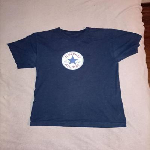

In [7]:
path = '/content/drive/MyDrive/M9/clothing-dataset-small-master/test/t-shirt/521ae02b-d891-4acd-8656-514a66312828.jpg'
img = load_img(path, target_size=(150, 150))
img

In [8]:
x = np.array(img)
X = np.array([x])
X = preprocess_input(X)

In [9]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [10]:
pred

array([[  0.24523425, -16.824833  ,   8.7229    , -16.28351   ,
        -17.806679  ,  -4.280014  , -24.238522  , -11.40533   ,
         -8.240928  ,  23.089518  ]], dtype=float32)

In [11]:
# classes = list(test_ds.class_indices.keys())
classes = ['dress',
 'hat',
 'longsleeve',
 'outwear',
 'pants',
 'shirt',
 'shoes',
 'shorts',
 'skirt',
 't-shirt']
classes

['dress',
 'hat',
 'longsleeve',
 'outwear',
 'pants',
 'shirt',
 'shoes',
 'shorts',
 'skirt',
 't-shirt']

In [12]:
dict(zip(classes, pred[0]))

{'dress': np.float32(0.24523425),
 'hat': np.float32(-16.824833),
 'longsleeve': np.float32(8.7229),
 'outwear': np.float32(-16.28351),
 'pants': np.float32(-17.806679),
 'shirt': np.float32(-4.280014),
 'shoes': np.float32(-24.238522),
 'shorts': np.float32(-11.40533),
 'skirt': np.float32(-8.240928),
 't-shirt': np.float32(23.089518)}